<a href="https://colab.research.google.com/github/MarcellaGuimaraesRodrigues/projeto-turismo-brasil/blob/main/analise_turismo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este trabalho analisa dados sobre o turismo no Brasil entre 2015 e 2024, com o objetivo de identificar os destinos mais visitados, a evolução do turismo ao longo dos anos, as diferenças entre as regiões e os fatores que influenciam o fluxo de turistas.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

url = "https://raw.githubusercontent.com/AlexandreLouzada/Dados-Simulados-G1/main/datasets_g1_30_temas/simulacao_turismo_brasil.csv"
df = pd.read_csv(url)
df["data"] = pd.to_datetime(df["data"])

print(df.shape)
df.info()
df.head()


(4440, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ano                    4440 non-null   int64         
 1   mes                    4440 non-null   int64         
 2   data                   4440 non-null   datetime64[ns]
 3   regiao                 4440 non-null   object        
 4   uf                     4440 non-null   object        
 5   cidade                 4440 non-null   object        
 6   turistas               4440 non-null   int64         
 7   turistas_estrangeiros  4440 non-null   int64         
 8   ocupacao_hoteleira     4440 non-null   float64       
 9   gasto_medio            4440 non-null   float64       
 10  faturamento_turismo    4440 non-null   float64       
 11  eventos_realizados     4440 non-null   int64         
 12  temperatura_media      4440 non-null   float64     

,ano,mes,data,regiao,uf,cidade,turistas,turistas_estrangeiros,ocupacao_hoteleira,gasto_medio,faturamento_turismo,eventos_realizados,temperatura_media,nivel_temporada
0,2015,1,2015-01-01,Norte,AM,Manaus,233689,47282,68.73,696.92,6.122438e+06,6,25.8,Média
1,2015,1,2015-01-01,Norte,PA,Belém,40837,41637,90.38,806.78,1.221923e+08,9,29.9,Baixa
2,2015,1,2015-01-01,Norte,PA,Santarém,393947,72315,89.25,1073.61,2.102537e+07,7,21.9,Baixa
3,2015,1,2015-01-01,Norte,RO,Porto Velho,278109,30614,91.51,237.15,7.601133e+07,8,25.5,Alta
4,2015,1,2015-01-01,Norte,TO,Palmas,282562,73139,76.32,791.34,1.663292e+08,5,28.6,Alta


In [ ]:

print("Valores nulos:\n", df.isnull().sum())
print("Duplicados:", df.duplicated().sum())

inconsistentes = df[df["turistas_estrangeiros"] > df["turistas"]]
print("Linhas com mais estrangeiros que o total:", len(inconsistentes))

Valores nulos:
 ano                      0
mes                      0
data                     0
regiao                   0
uf                       0
cidade                   0
turistas                 0
turistas_estrangeiros    0
ocupacao_hoteleira       0
gasto_medio              0
faturamento_turismo      0
eventos_realizados       0
temperatura_media        0
nivel_temporada          0
dtype: int64
Duplicados: 0
Linhas com mais estrangeiros que o total: 260


A base não tinha valores nulos nem registros duplicados. Porém, encontrei 260 linhas em que o número de turistas estrangeiros era maior que o total de turistas. Eu igualei o número de estrangeiros ao total de turistas

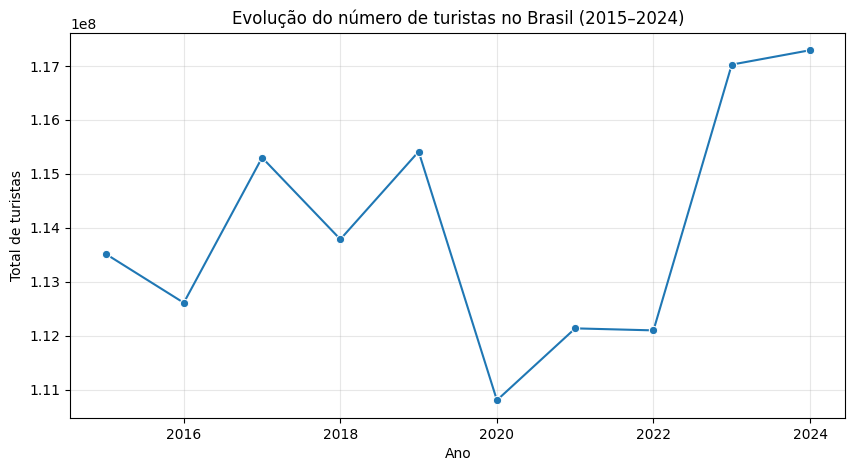

In [ ]:

turistas_ano = df.groupby("ano")["turistas"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=turistas_ano, x="ano", y="turistas", marker="o")
plt.title("Evolução do número de turistas no Brasil (2015–2024)")
plt.xlabel("Ano")
plt.ylabel("Total de turistas")
plt.grid(True, alpha=0.3)
plt.show()

Evolução do turismo (2015–2024): O número de turistas no Brasil se manteve relativamente estável ao longo do período, em torno de 110 a 117 milhões por ano. O ponto mais baixo foi em 2020, provavelmente por causa da pandemia de COVID-19. A partir de 2023, houve recuperação, e 2024 registrou o maior número de turistas da série.

In [ ]:

df["turistas_estrangeiros"] = df[["turistas_estrangeiros", "turistas"]].min(axis=1)


df["perc_estrangeiros"] = (df["turistas_estrangeiros"] / df["turistas"] * 100).round(2)
df["faturamento_por_turista"] = (df["faturamento_turismo"] / df["turistas"]).round(2)
df["nome_mes"] = df["data"].dt.strftime("%b")

print("Inconsistências restantes:", (df["turistas_estrangeiros"] > df["turistas"]).sum())
df.head()

Inconsistências restantes: 0


,ano,mes,data,regiao,uf,cidade,turistas,turistas_estrangeiros,ocupacao_hoteleira,gasto_medio,faturamento_turismo,eventos_realizados,temperatura_media,nivel_temporada,perc_estrangeiros,faturamento_por_turista,nome_mes
0,2015,1,2015-01-01,Norte,AM,Manaus,233689,47282,68.73,696.92,6.122438e+06,6,25.8,Média,20.23,26.20,Jan
1,2015,1,2015-01-01,Norte,PA,Belém,40837,40837,90.38,806.78,1.221923e+08,9,29.9,Baixa,100.00,2992.19,Jan
2,2015,1,2015-01-01,Norte,PA,Santarém,393947,72315,89.25,1073.61,2.102537e+07,7,21.9,Baixa,18.36,53.37,Jan
3,2015,1,2015-01-01,Norte,RO,Porto Velho,278109,30614,91.51,237.15,7.601133e+07,8,25.5,Alta,11.01,273.31,Jan
4,2015,1,2015-01-01,Norte,TO,Palmas,282562,73139,76.32,791.34,1.663292e+08,5,28.6,Alta,25.88,588.65,Jan


In [ ]:

total_turistas = df["turistas"].sum()
faturamento_total = df["faturamento_turismo"].sum()
ocupacao_media = df["ocupacao_hoteleira"].mean()
gasto_medio = df["gasto_medio"].mean()
cidade_top = df.groupby("cidade")["turistas"].sum().idxmax()
regiao_top = df.groupby("regiao")["faturamento_turismo"].sum().idxmax()

print(f"Total de turistas: {total_turistas:,.0f}")
print(f"Faturamento total: R$ {faturamento_total:,.2f}")
print(f"Ocupação hoteleira média: {ocupacao_media:.1f}%")
print(f"Gasto médio por turista: R$ {gasto_medio:.2f}")
print(f"Cidade mais visitada: {cidade_top}")
print(f"Região com maior faturamento: {regiao_top}")

Total de turistas: 1,139,968,982
Faturamento total: R$ 443,225,344,527.85
Ocupação hoteleira média: 60.4%
Gasto médio por turista: R$ 675.71
Cidade mais visitada: Aparecida de Goiânia
Região com maior faturamento: Sudeste


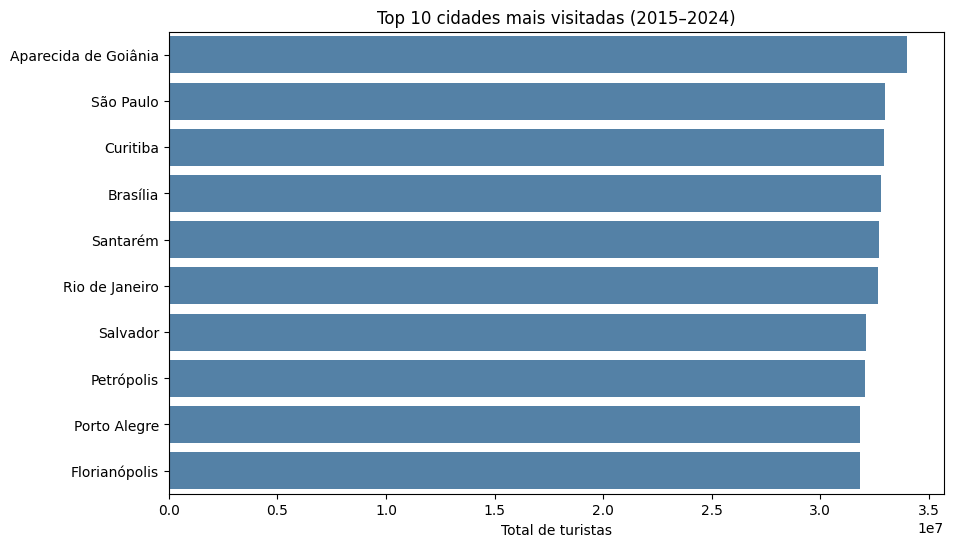

In [ ]:

top_cidades = df.groupby("cidade")["turistas"].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_cidades, x="turistas", y="cidade", color="steelblue")
plt.title("Top 10 cidades mais visitadas (2015–2024)")
plt.xlabel("Total de turistas")
plt.ylabel("")
plt.show()

Cidades mais visitadas: No período analisado, Aparecida de Goiânia (GO) foi a cidade que mais recebeu turistas, à frente de São Paulo, Curitiba e Brasília. A diferença entre as dez primeiras colocadas é pequena, todas entre 31 e 34 milhões de turistas, o que mostra uma distribuição bem equilibrada entre os destinos.

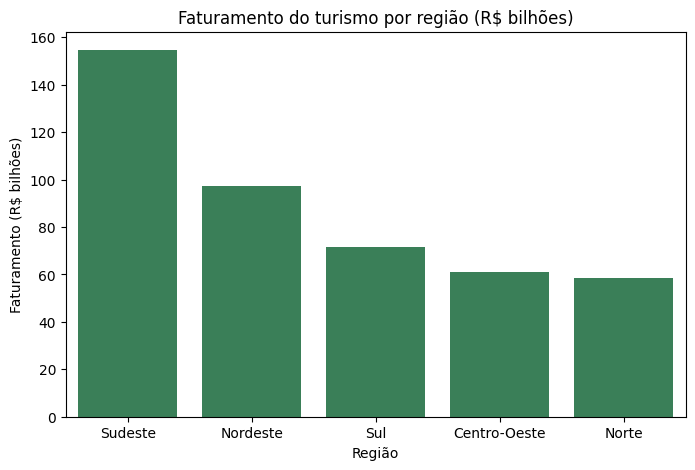

In [ ]:

fat_regiao = df.groupby("regiao")["faturamento_turismo"].sum().sort_values(ascending=False).reset_index()
fat_regiao["faturamento_bi"] = fat_regiao["faturamento_turismo"] / 1e9

plt.figure(figsize=(8, 5))
sns.barplot(data=fat_regiao, x="regiao", y="faturamento_bi", color="seagreen")
plt.title("Faturamento do turismo por região (R$ bilhões)")
plt.xlabel("Região")
plt.ylabel("Faturamento (R$ bilhões)")
plt.show()

Faturamento por região: A região Sudeste apresentou o maior faturamento com turismo no período (R$ 154,6 bilhões), enquanto a região Norte teve o menor (R$ 58,6 bilhões). Essa diferença acontece principalmente porque o Sudeste tem mais cidades turísticas na base (13, contra 5 do Norte). Quando o faturamento é dividido pelo número de cidades, todas as regiões ficam muito parecidas, em torno de R$ 12 bilhões por cidade.

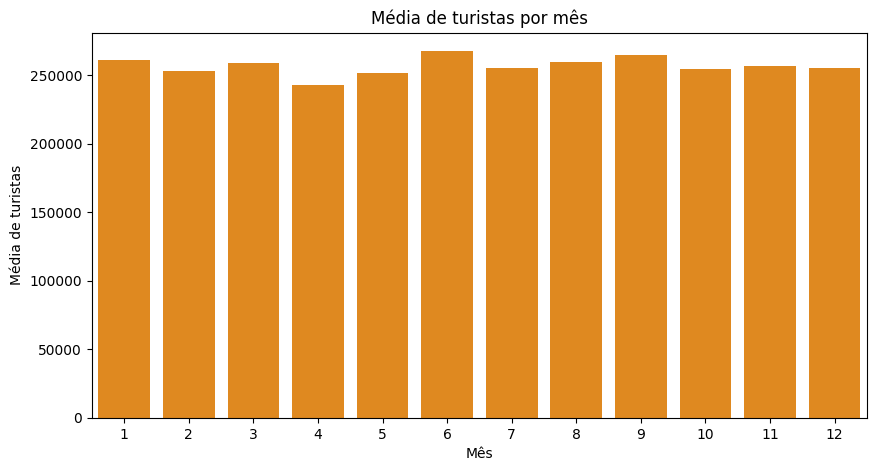

In [ ]:

turistas_mes = df.groupby("mes")["turistas"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=turistas_mes, x="mes", y="turistas", color="darkorange")
plt.title("Média de turistas por mês")
plt.xlabel("Mês")
plt.ylabel("Média de turistas")
plt.show()

Sazonalidade: No geral, a média de turistas é bem parecida ao longo dos meses, sem uma alta temporada muito marcada. Junho apresenta a maior média (cerca de 268 mil turistas) e abril a menor (cerca de 243 mil), uma diferença de aproximadamente 10%. Além disso, o rótulo "nível de temporada" da base não acompanha o movimento real: os períodos classificados como "Baixa" tiveram média de turistas ligeiramente maior que os de "Alta".

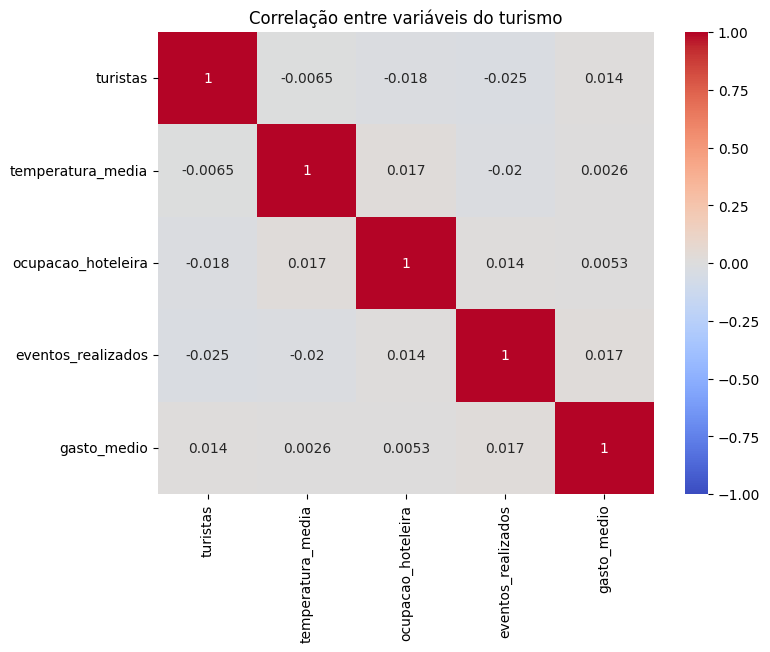

In [ ]:

colunas = ["turistas", "temperatura_media", "ocupacao_hoteleira", "eventos_realizados", "gasto_medio"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[colunas].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação entre variáveis do turismo")
plt.show()

Clima x turismo: A correlação entre a temperatura média e o número de turistas foi praticamente zero (-0,01), o que indica que o clima não influencia o fluxo turístico nesta base. As outras variáveis analisadas (ocupação hoteleira, eventos realizados e gasto médio) também apresentaram correlação próxima de zero com o número de turistas.

Conclusão: A análise do turismo no Brasil entre 2015 e 2024 trouxe três descobertas principais. Primeiro, a região Sudeste é a que mais fatura com turismo, principalmente por concentrar o maior número de cidades turísticas. Segundo, o clima não influencia o fluxo de turistas, já que a correlação entre temperatura e número de visitantes foi praticamente zero. Por fim, o ranking das cidades mais visitadas surpreende: Aparecida de Goiânia aparece em primeiro lugar, à frente de destinos tradicionais como Rio de Janeiro e Salvador. Como a base de dados é simulada, esses resultados servem para praticar técnicas de análise e não representam necessariamente a realidade do turismo brasileiro.